In [16]:
# Import basic libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

# Explainability
import shap


In [17]:
df = pd.read_csv("bank.csv", sep=";")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  durations  campaign  pdays  previous poutcome   y  
0  unknown    5   may        261         1     -1         0  unknown  no  
1  unknown    5   may        151         1     -1         0  unknown  no  
2  unknown    5   may         76         1     -1         0  unknown  no  
3  unknown    5   may         92         1     -1         0  unknown  no  
4  unknown    5   may        198         1     -1         0  unknown  no  

Dataset shape:
(45210, 17)


In [18]:
# STEP 4: Encode categorical features

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("\nCategorical encoding completed")



Categorical encoding completed


In [19]:
# STEP 5: Define X and y

X = df.drop("y", axis=1)
y = df["y"]

print("\nFeature columns:")
print(X.columns)



Feature columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'durations', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')


In [21]:
# STEP 6: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)






Train shape: (36168, 16)
Test shape: (9042, 16)


In [22]:
# STEP 7: Scale features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [23]:
# STEP 8: Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("\nLogistic Regression training completed")



Logistic Regression training completed


In [24]:
# STEP 9: Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest training completed")



Random Forest training completed


In [25]:
# STEP 10: Confusion Matrix

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))



Logistic Regression Confusion Matrix:
[[7792  157]
 [ 863  230]]

Random Forest Confusion Matrix:
[[7764  185]
 [ 707  386]]


In [26]:
# STEP 11: F1 Score

print("\nLogistic Regression F1 Score:",
      f1_score(y_test, lr_pred))

print("Random Forest F1 Score:",
      f1_score(y_test, rf_pred))



Logistic Regression F1 Score: 0.3108108108108108
Random Forest F1 Score: 0.4639423076923077


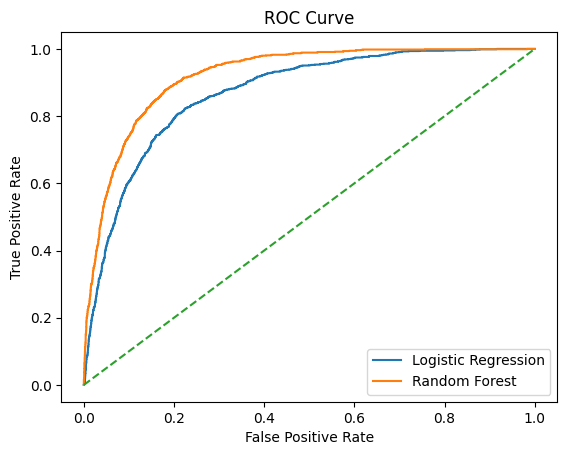

In [27]:
# STEP 12: ROC Curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure()

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [28]:
# STEP 13: AUC Score

print("\nLogistic Regression AUC:",
      roc_auc_score(y_test, lr_prob))

print("Random Forest AUC:",
      roc_auc_score(y_test, rf_prob))



Logistic Regression AUC: 0.868405596197258
Random Forest AUC: 0.9203293595021418


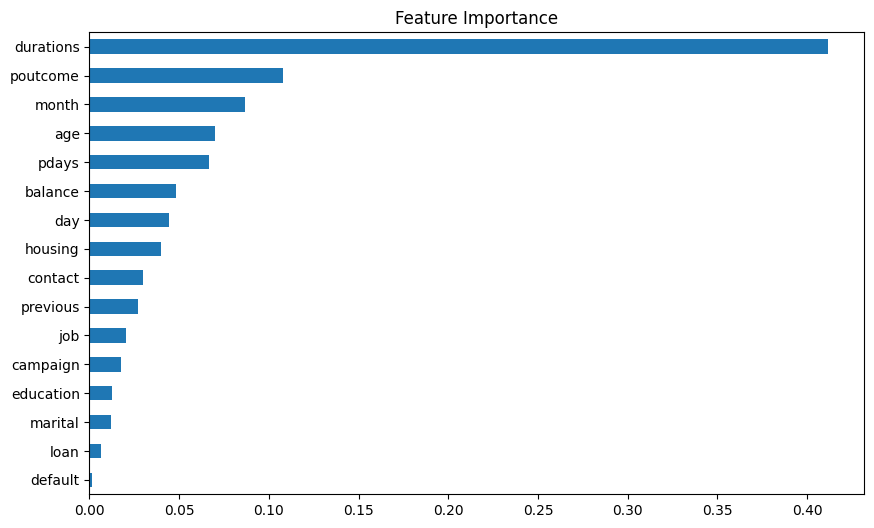

In [29]:
# STEP 14: Feature Importance

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()


In [30]:
# STEP 15: SHAP Explainability

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)


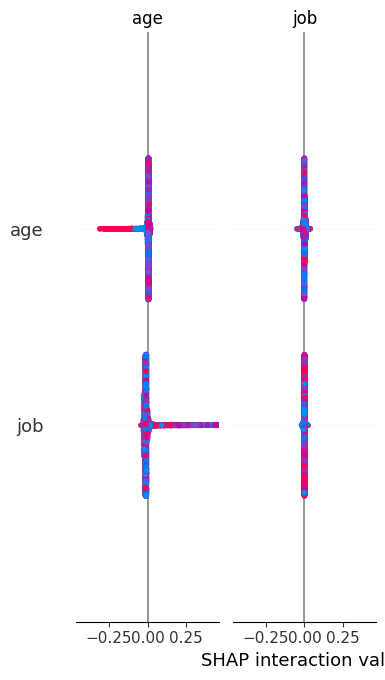

In [32]:
# Global explanation

shap.summary_plot(shap_values, X_test)



100%|===================| 18065/18084 [13:55<00:00]        

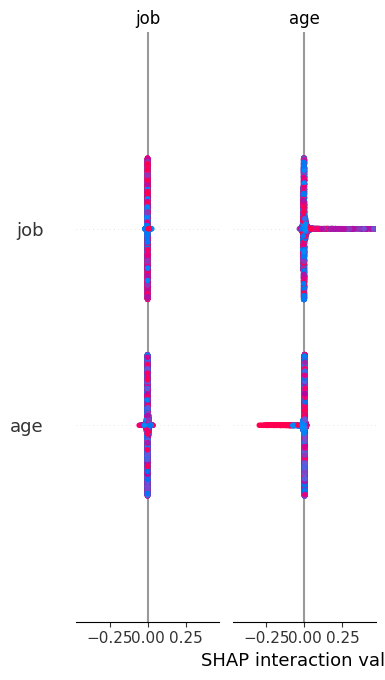

Explaining prediction 1


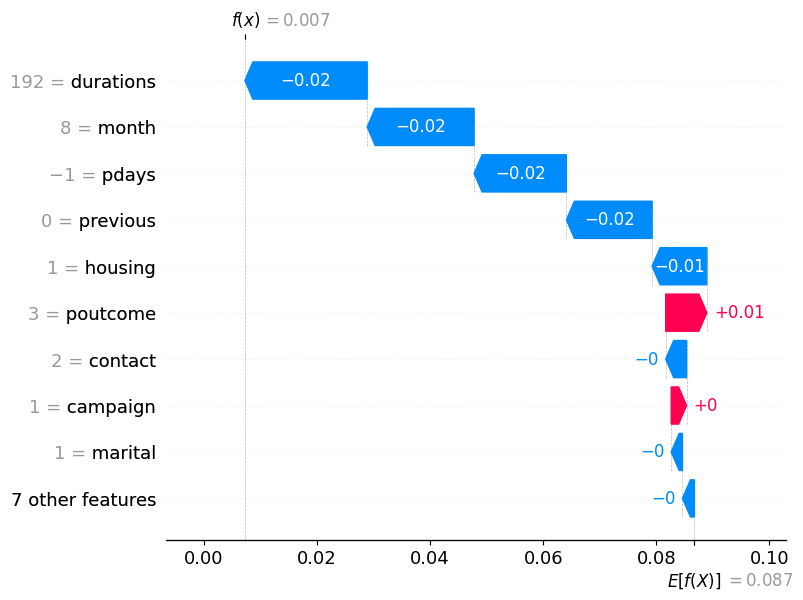

Explaining prediction 2


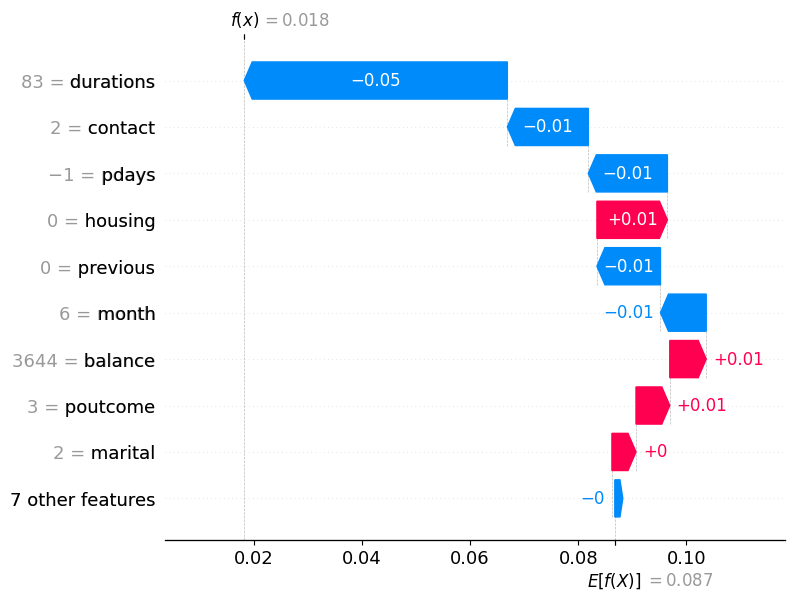

Explaining prediction 3


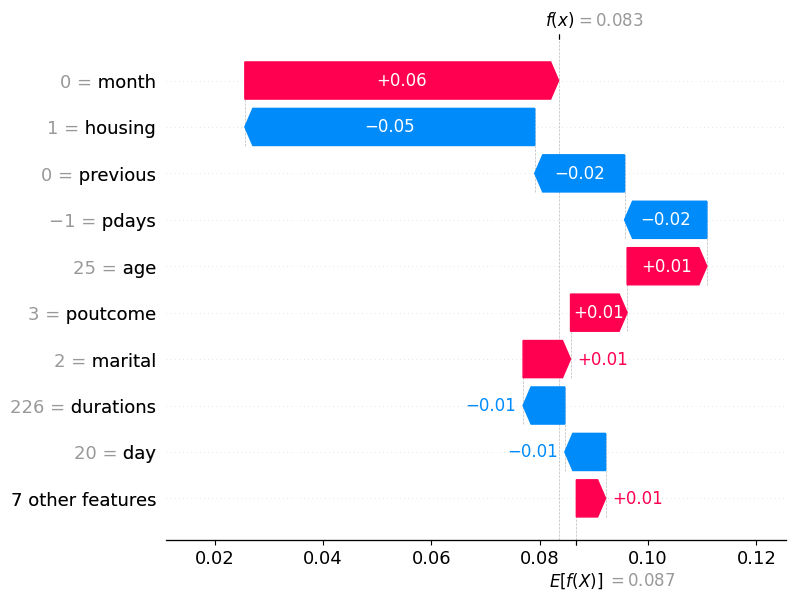

Explaining prediction 4


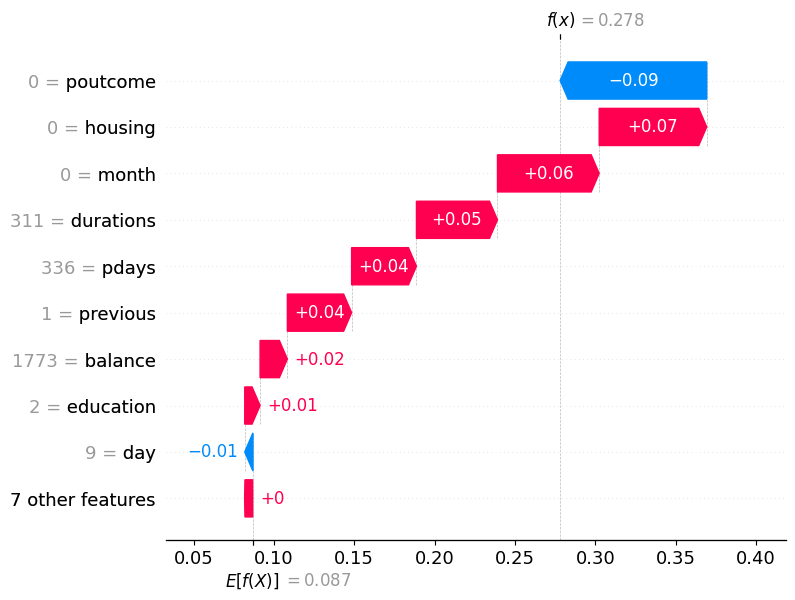

Explaining prediction 5


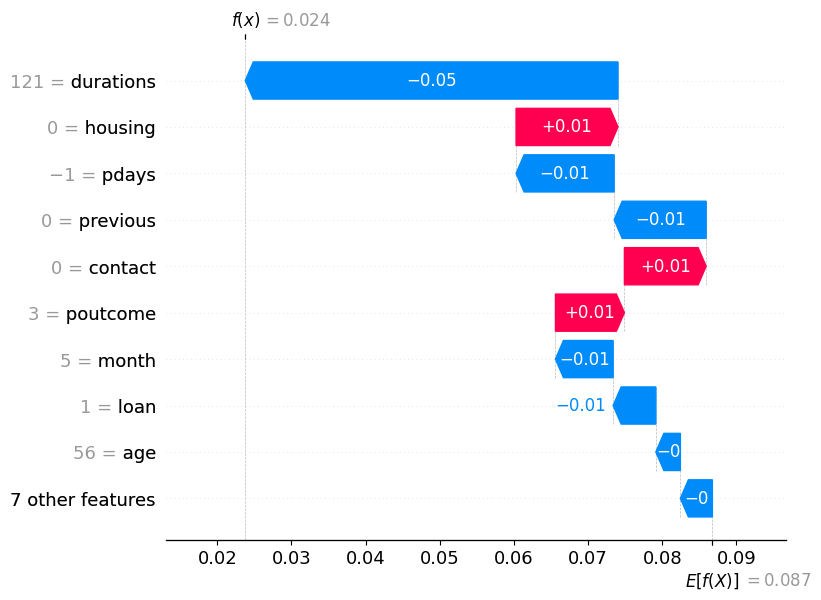

In [36]:
import shap

# Create Explainer
explainer = shap.Explainer(rf, X_train)

# Get SHAP values
shap_values = explainer(X_test)

# Global Explanation
shap.summary_plot(shap_values)

# Explain 5 individual predictions (for class 1)
for i in range(5):
    print(f"Explaining prediction {i+1}")
    shap.plots.waterfall(shap_values[i][:,1])   # [:,1] selects class 1
